<a href="https://colab.research.google.com/github/mullinskatie7-source/Programming-for-Engineers/blob/main/Katherine_Mullins_VanderWaalsGasAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Van der Waals Gas Analysis: CO₂

**Engineer:** Katherine Mullins

**Completion Date:** 06/13/2026

**Class:** EGN3214

**Assignment #:** 4

**Tool Used:** Colab / Python

## Problem Description

The goal is to find out which gas model is better at predicting the pressure of carbon dioxide under conditions. There is a dataset of 20 experiments with temperature, volume, moles of gas and the actual pressure. For each experiment we calculate the pressure using two models: the Ideal Gas Law and the Van der Waals equation and compare these predicted pressures to the pressure measured in the experiment. To see how good each model is, we calculate the percent error, see if it is within range, and then calculate the differences between both models to compare to the sensor’s accuracy limit. A percent error close to zero is good because it means the model and experiment agree. A large positive or negative percent error means the model is predicting or under-predicting. The pressure sensor we used has an accuracy of plus or minus 1.5%.

## Methodology

The analysis was completed using Python in a Colab notebook. First, the required Python modules were imported, including csv for reading and writing CSV files, math for calculations, pathlib and os for file handling, and matplotlib for plotting. The experimental CO₂ data was stored in a CSV file and read into the program using csv.DictReader. Since CSV files store values as text, the numerical values for temperature, volume, moles, and measured pressure were converted to floating-point numbers before calculations were performed.


Three main calculation functions were used in the program. The first function calculated predicted pressure using the Ideal Gas Law, the second calculated predicted pressure using the Van der Waals equation, and the third calculated percent error between predicted and measured pressure. The program stored each trial’s original data and calculated results in a list of dictionaries. After processing all trials, the results were written to a new CSV file using csv.DictWriter. Finally, two plots were created: one comparing measured and predicted pressures, and another showing percent error for both models compared to the ±1.5% sensor accuracy band.
The equations given are:
The Ideal Gas Law: PV = nRT (simplified model)
The Van der Waals Equation: (P + a·n²/V²)(V − n·b) = nRT (corrected model)



Input file created: co2_experimental_data.csv
Current working directory: /content
Imported CSV Data:
--------------------------------------------------------------------------------
{'trial_id': '1', 'temperature_K': '300.0', 'volume_m3': '0.002500', 'n_mol': '1.000', 'measured_pressure_Pa': '997200'}
{'trial_id': '2', 'temperature_K': '300.0', 'volume_m3': '0.003000', 'n_mol': '1.000', 'measured_pressure_Pa': '829500'}
{'trial_id': '3', 'temperature_K': '300.0', 'volume_m3': '0.004000', 'n_mol': '1.000', 'measured_pressure_Pa': '621800'}
{'trial_id': '4', 'temperature_K': '300.0', 'volume_m3': '0.005000', 'n_mol': '1.000', 'measured_pressure_Pa': '497100'}
{'trial_id': '5', 'temperature_K': '325.0', 'volume_m3': '0.002500', 'n_mol': '1.000', 'measured_pressure_Pa': '1079600'}
{'trial_id': '6', 'temperature_K': '325.0', 'volume_m3': '0.003000', 'n_mol': '1.000', 'measured_pressure_Pa': '898200'}
{'trial_id': '7', 'temperature_K': '325.0', 'volume_m3': '0.004000', 'n_mol': '1.000', 'mea

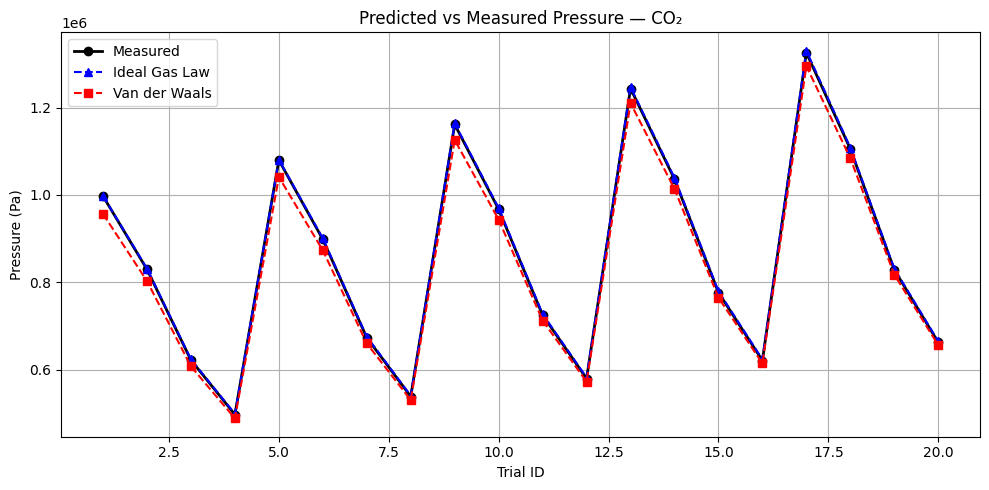

Plot 1 saved as pressure_comparison.png


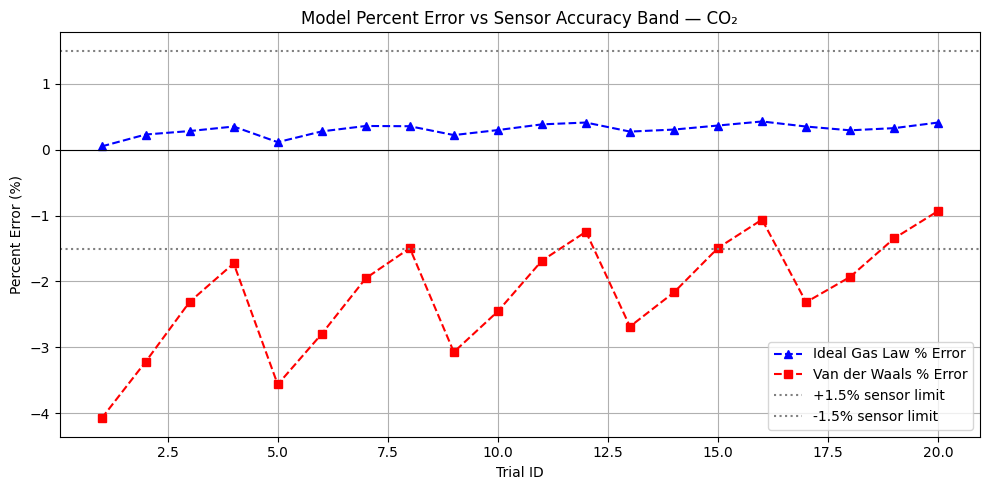

Plot 2 saved as percent_error_comparison.png
Summary Error Metrics
----------------------------------------
Average absolute percent error, Ideal Gas Law: 0.304%
Average absolute percent error, Van der Waals: 2.176%
Ideal Gas Law trials within ±1.5% sensor error: 20 of 20
Van der Waals trials within ±1.5% sensor error: 6 of 20


In [8]:
# Step 2: Import required modules and define constants
import math
import csv
import os
import sys
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt

# Constants for calculations
R = 8.314                     # Universal gas constant, J/(mol*K)
A_VDW = 0.3658                # Van der Waals constant a for CO2, Pa*m^6/mol^2
B_VDW = 4.286e-5              # Van der Waals constant b for CO2, m^3/mol
SENSOR_ERROR_PCT = 1.5        # Pressure sensor accuracy, percent

# File names
INPUT_FILE = "co2_experimental_data.csv"
OUTPUT_FILE = "co2_processed_results.csv"

# Step 3: Create the input CSV file from the provided experimental data

csv_data = """trial_id,temperature_K,volume_m3,n_mol,measured_pressure_Pa
1,300.0,0.002500,1.000,997200
2,300.0,0.003000,1.000,829500
3,300.0,0.004000,1.000,621800
4,300.0,0.005000,1.000,497100
5,325.0,0.002500,1.000,1079600
6,325.0,0.003000,1.000,898200
7,325.0,0.004000,1.000,673100
8,325.0,0.005000,1.000,538500
9,350.0,0.002500,1.000,1161400
10,350.0,0.003000,1.000,967100
11,350.0,0.004000,1.000,724700
12,350.0,0.005000,1.000,579600
13,375.0,0.002500,1.000,1243700
14,375.0,0.003000,1.000,1036100
15,375.0,0.004000,1.000,776600
16,375.0,0.005000,1.000,620900
17,400.0,0.002500,1.000,1325600
18,400.0,0.003000,1.000,1105300
19,400.0,0.004000,1.000,828700
20,400.0,0.005000,1.000,662400
"""

with open(INPUT_FILE, "w", newline="") as file:
    file.write(csv_data)

print(f"Input file created: {INPUT_FILE}")
print(f"Current working directory: {os.getcwd()}")

# Step 4: Read the input CSV file and print the imported data
with open(INPUT_FILE, "r", newline="") as file:
    reader = csv.DictReader(file)

    print("Imported CSV Data:")
    print("-" * 80)

    for row in reader:
        print(row)

# Step 5: Define calculation functions
def ideal_gas_pressure(n, R, T, V):
    """
    Calculate pressure using the Ideal Gas Law.

    Parameters:
    n : float — moles of gas
    R : float — gas constant, J/(mol*K)
    T : float — temperature in Kelvin
    V : float — volume in cubic meters

    Returns:
    Pressure in Pa
    """
    return (n * R * T) / V


def vdw_pressure(n, R, T, V, a, b):
    """
    Calculate pressure using the Van der Waals equation.

    Parameters:
    n : float — moles of gas
    R : float — gas constant, J/(mol*K)
    T : float — temperature in Kelvin
    V : float — volume in cubic meters
    a : float — Van der Waals constant a
    b : float — Van der Waals constant b

    Returns:
    Pressure in Pa
    """
    return (n * R * T) / (V - n * b) - (a * n**2) / (V**2)


def percent_error(predicted, measured):
    """
    Calculate percent error between predicted and measured pressure.

    Parameters:
    predicted : float — model predicted pressure
    measured : float — experimental measured pressure

    Returns:
    Percent error
    """
    return ((predicted - measured) / measured) * 100

# Step 6: Read the CSV file and compute results

results = []  # This list will store one dictionary for each trial

with open(INPUT_FILE, "r", newline="") as file:
    reader = csv.DictReader(file)

    for row in reader:
        # Convert CSV string values to numeric values
        trial_id = int(row["trial_id"])
        temperature_K = float(row["temperature_K"])
        volume_m3 = float(row["volume_m3"])
        n_mol = float(row["n_mol"])
        measured_pressure_Pa = float(row["measured_pressure_Pa"])

        # Calculate predicted pressures
        p_ideal = ideal_gas_pressure(n_mol, R, temperature_K, volume_m3)
        p_vdw = vdw_pressure(n_mol, R, temperature_K, volume_m3, A_VDW, B_VDW)

        # Calculate percent errors
        pct_err_ideal = percent_error(p_ideal, measured_pressure_Pa)
        pct_err_vdw = percent_error(p_vdw, measured_pressure_Pa)

        # Store original and calculated values
        result_row = {
            "trial_id": trial_id,
            "temperature_K": temperature_K,
            "volume_m3": volume_m3,
            "n_mol": n_mol,
            "measured_pressure_Pa": measured_pressure_Pa,
            "p_ideal_Pa": p_ideal,
            "p_vdw_Pa": p_vdw,
            "pct_err_ideal": pct_err_ideal,
            "pct_err_vdw": pct_err_vdw
        }

        results.append(result_row)

print(f"Total trials processed: {len(results)}")

# Step 7: Write processed results to a new CSV file

fieldnames = [
    "trial_id",
    "temperature_K",
    "volume_m3",
    "n_mol",
    "measured_pressure_Pa",
    "p_ideal_Pa",
    "p_vdw_Pa",
    "pct_err_ideal",
    "pct_err_vdw"
]

with open(OUTPUT_FILE, "w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)

    writer.writeheader()

    for row in results:
        writer.writerow(row)

print(f"Processed results written to: {OUTPUT_FILE}")

# Step 8: Extract data for plotting

trial_ids = [r["trial_id"] for r in results]
measured = [r["measured_pressure_Pa"] for r in results]
p_ideal_list = [r["p_ideal_Pa"] for r in results]
p_vdw_list = [r["p_vdw_Pa"] for r in results]
pct_ideal_list = [r["pct_err_ideal"] for r in results]
pct_vdw_list = [r["pct_err_vdw"] for r in results]

# Plot 1: Predicted vs Measured Pressure

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(trial_ids, measured, "ko-", label="Measured", linewidth=2)
ax.plot(trial_ids, p_ideal_list, "b^--", label="Ideal Gas Law")
ax.plot(trial_ids, p_vdw_list, "rs--", label="Van der Waals")

ax.set_xlabel("Trial ID")
ax.set_ylabel("Pressure (Pa)")
ax.set_title("Predicted vs Measured Pressure — CO₂")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("pressure_comparison.png", dpi=150)
plt.show()

print("Plot 1 saved as pressure_comparison.png")

# Plot 2: Percent Error by Trial

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(trial_ids, pct_ideal_list, "b^--", label="Ideal Gas Law % Error")
ax.plot(trial_ids, pct_vdw_list, "rs--", label="Van der Waals % Error")

ax.axhline(y=SENSOR_ERROR_PCT, color="gray", linestyle=":", label="+1.5% sensor limit")
ax.axhline(y=-SENSOR_ERROR_PCT, color="gray", linestyle=":", label="-1.5% sensor limit")
ax.axhline(y=0, color="black", linewidth=0.8)

ax.set_xlabel("Trial ID")
ax.set_ylabel("Percent Error (%)")
ax.set_title("Model Percent Error vs Sensor Accuracy Band — CO₂")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("percent_error_comparison.png", dpi=150)
plt.show()

print("Plot 2 saved as percent_error_comparison.png")

# Step 9: Calculate summary error metrics

ideal_abs_errors = [abs(r["pct_err_ideal"]) for r in results]
vdw_abs_errors = [abs(r["pct_err_vdw"]) for r in results]

avg_abs_error_ideal = sum(ideal_abs_errors) / len(ideal_abs_errors)
avg_abs_error_vdw = sum(vdw_abs_errors) / len(vdw_abs_errors)

ideal_within_sensor = sum(1 for err in ideal_abs_errors if err <= SENSOR_ERROR_PCT)
vdw_within_sensor = sum(1 for err in vdw_abs_errors if err <= SENSOR_ERROR_PCT)

print("Summary Error Metrics")
print("-" * 40)
print(f"Average absolute percent error, Ideal Gas Law: {avg_abs_error_ideal:.3f}%")
print(f"Average absolute percent error, Van der Waals: {avg_abs_error_vdw:.3f}%")
print(f"Ideal Gas Law trials within ±{SENSOR_ERROR_PCT}% sensor error: {ideal_within_sensor} of {len(results)}")
print(f"Van der Waals trials within ±{SENSOR_ERROR_PCT}% sensor error: {vdw_within_sensor} of {len(results)}")